# Our World In Data

### Viktoria Ivanova - 7MI3400799

In this project, advanced research on [https://ourworldindata.org/](https://ourworldindata.org/) webpage will be performed in order to find interesting and intriguing information about Our World In Data. 
Questions will be asked, assumptions will be concluded, visualizations will be showed, and most important, decisions will be taken.

### Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

### Obtaining the data

Data about Happiness, Life expectancy, Political corruption, Government trust and Healthcare spendings will be downloaded to obtain some useful or even surprising information about the countries.

In [80]:
happiness_df = pd.read_csv("share-of-people-who-say-they-are-happy.csv")
life_expectancy_df = pd.read_csv("life-satisfaction-vs-life-expectancy.csv")
life_satisfaction_df = pd.read_csv("life-satisfaction-vs-life-expectancy.csv")
healthcare_df = pd.read_csv("total-healthcare-expenditure-gdp.csv")
corruption_df = pd.read_csv("political-corruption-index.csv")
gdp_per_capita_df = pd.read_csv("gdp-per-capita-worldbank.csv")

Separately, for each of the dataframes will check which are the meaningful features for the task and decide what correlations can be found out.

In [3]:
happiness_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Entity                        425 non-null    object 
 1   Code                          420 non-null    object 
 2   Year                          425 non-null    int64  
 3   Happiness: Happy (aggregate)  425 non-null    float64
 4   1076736-annotations           5 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 16.7+ KB


In [32]:
happiness_df["Country"].drop_duplicates()

0        Albania
4        Algeria
6        Andorra
8      Argentina
15       Armenia
         ...    
414    Venezuela
417      Vietnam
420        Yemen
421       Zambia
422     Zimbabwe
Name: Country, Length: 118, dtype: object

In [36]:
happiness_df["Year"].drop_duplicates()

0    1998
1    2004
2    2010
3    2022
5    2014
8    1984
9    1993
Name: Year, dtype: int64

To summarize, we will go through 118 countries in 7 different years.

In [8]:
happiness_df = happiness_df.rename(columns={'Happiness: Happy (aggregate)': 'Happiness'})
happiness_df = happiness_df.rename(columns={'Entity': 'Country'})

Based on the summarized information about the dataset, we can use the Happiness, Year and Country columns to give some results. Furst of all, statistical data could be used to check how happy are the people through the years overal.

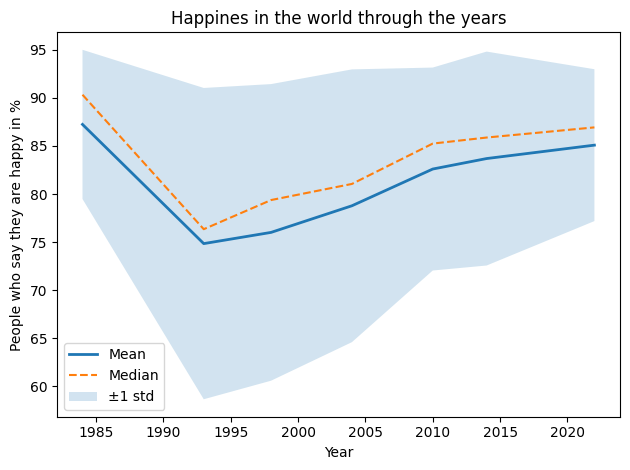

In [ ]:
summary = (
    happiness_df.groupby("Year")["Happiness"]
      .agg(["mean", "median", "std", "count"])
      .reset_index()
)

plt.plot(summary["Year"], summary["mean"], label="Mean", linewidth=2)
plt.plot(summary["Year"], summary["median"], linestyle="--", label="Median")

plt.fill_between(
    summary["Year"],
    summary["mean"] - summary["std"],
    summary["mean"] + summary["std"],
    alpha=0.2,
    label="±1 std"
)

plt.xlabel("Year")
plt.ylabel("People who say they are happy in %")
plt.title("Happines in the world through the years")
plt.legend()
plt.tight_layout()
plt.show()

If the retrieved data before 1985 is correct, seems that we have what to improve in 21st century if we want to be as happy as people were 30 years ago. However, most probably the global crisis in the 90s made such a decline among the people happiness.

Let's now check how each of the countries felt during the years.

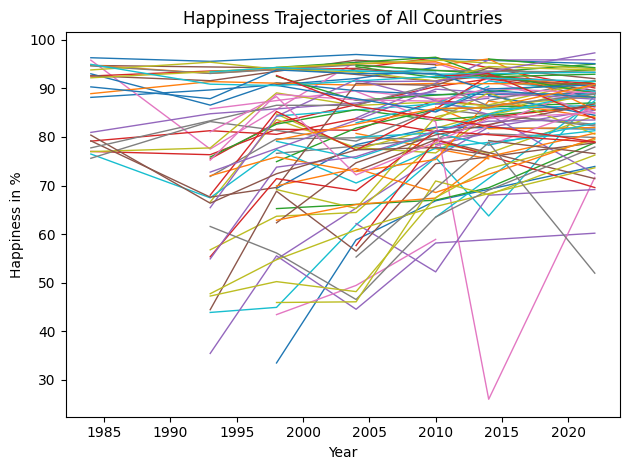

In [15]:
for country, g in happiness_df.groupby("Country"):
    plt.plot(g["Year"], g["Happiness"], linewidth=1)

plt.xlabel("Year")
plt.ylabel("Happiness in %")
plt.title("Happiness Trajectories of All Countries")
plt.tight_layout()
plt.show()

Seems like the overal tendency is that people over the world are becoming happier. Only some major drops are visible but the whole picture is not that negative.

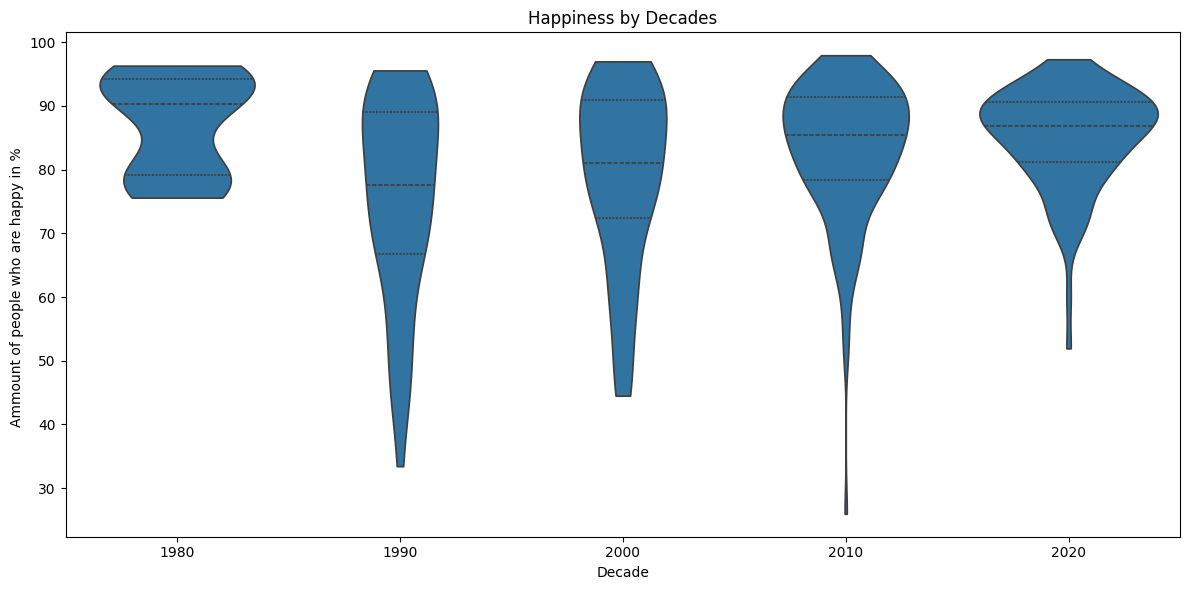

In [17]:
happiness_df["Decade"] = (happiness_df["Year"] // 10) * 10

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=happiness_df,
    x="Decade",
    y="Happiness",
    inner="quartile",
    cut=0
)

plt.xlabel("Decade")
plt.ylabel("Ammount of people who are happy in % ")
plt.title("Happiness by Decades")
plt.tight_layout()
plt.show()

The ammount of happy people is increaing over the decades, despite the decline between 80s and 90s. This is a good sign for an improving world happines, economy, peace and many more.

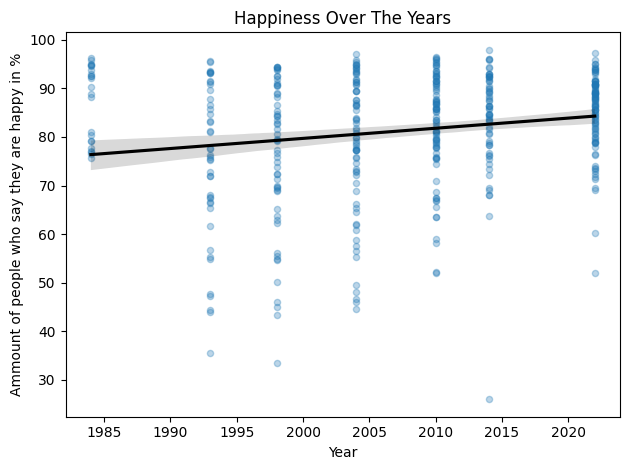

In [19]:
sns.regplot(
    data=happiness_df,
    x="Year",
    y="Happiness",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "black"},
    ci=95
)

plt.xlabel("Year")
plt.ylabel("Ammount of people who say they are happy in %")
plt.title("Happiness Over The Years")
plt.tight_layout()
plt.show()

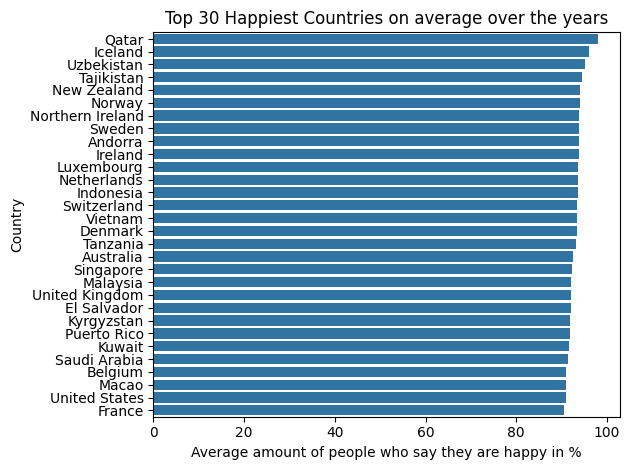

In [37]:
avg_by_country = (
    happiness_df.groupby("Country")["Happiness"]
      .mean()
      .reset_index()
      .sort_values("Happiness", ascending=False)
)


sns.barplot(
    data=avg_by_country.head(30),
    x="Happiness",
    y="Country"
)

plt.xlabel("Average amount of people who say they are happy in %")
plt.ylabel("Country")
plt.title("Top 30 Happiest Countries on average over the years")
plt.tight_layout()
plt.show()

Unfortunately, Bulgaria is not part of the 30 happiest countries. The results, however, are not that surprising, the richer the country is, the happier the people are.

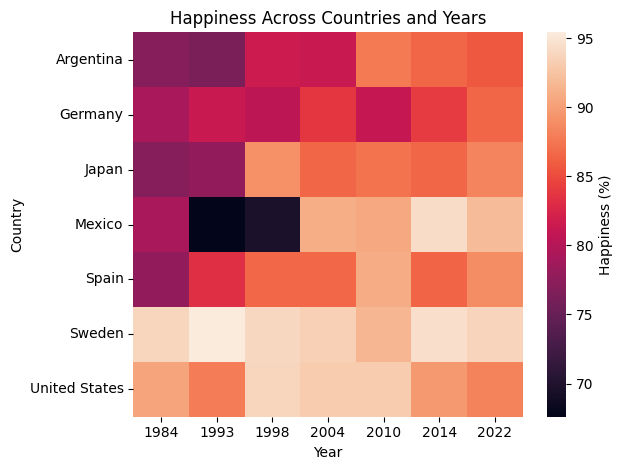

In [41]:
heatmap_data = (
    happiness_df.pivot_table(
        index="Country",
        columns="Year",
        values="Happiness"
    )
)

pivot = heatmap_data.dropna()
sns.heatmap(
    pivot,
    cbar_kws={"label": "Happiness (%)"}
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.title("Happiness Across Countries and Years")
plt.tight_layout()
plt.show()

Comparing only the countries which have the full data provided, the world is becoming happier.

### Let's now investigate some other parameters which can be later combined.

In [5]:
healthcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545 entries, 0 to 4544
Data columns (total 4 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   Entity                                                                              4545 non-null   object 
 1   Code                                                                                4407 non-null   object 
 2   Year                                                                                4545 non-null   int64  
 3   Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)  4545 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 142.2+ KB


In [43]:
healthcare_df = healthcare_df.rename(columns={'Entity': 'Country'})
healthcare_df = healthcare_df.rename(columns={'Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)': 'Health_expenditure'})

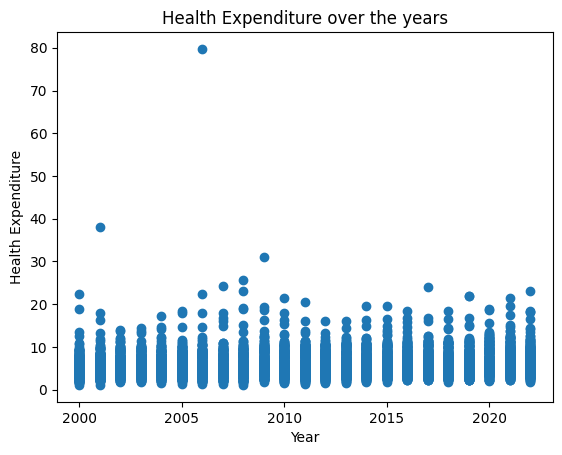

In [53]:
plt.figure()
plt.scatter(healthcare_df["Year"], healthcare_df["Health_expenditure"])
plt.xlabel("Year")
plt.ylabel("Health Expenditure")
plt.title("Health Expenditure over the years")
plt.show()

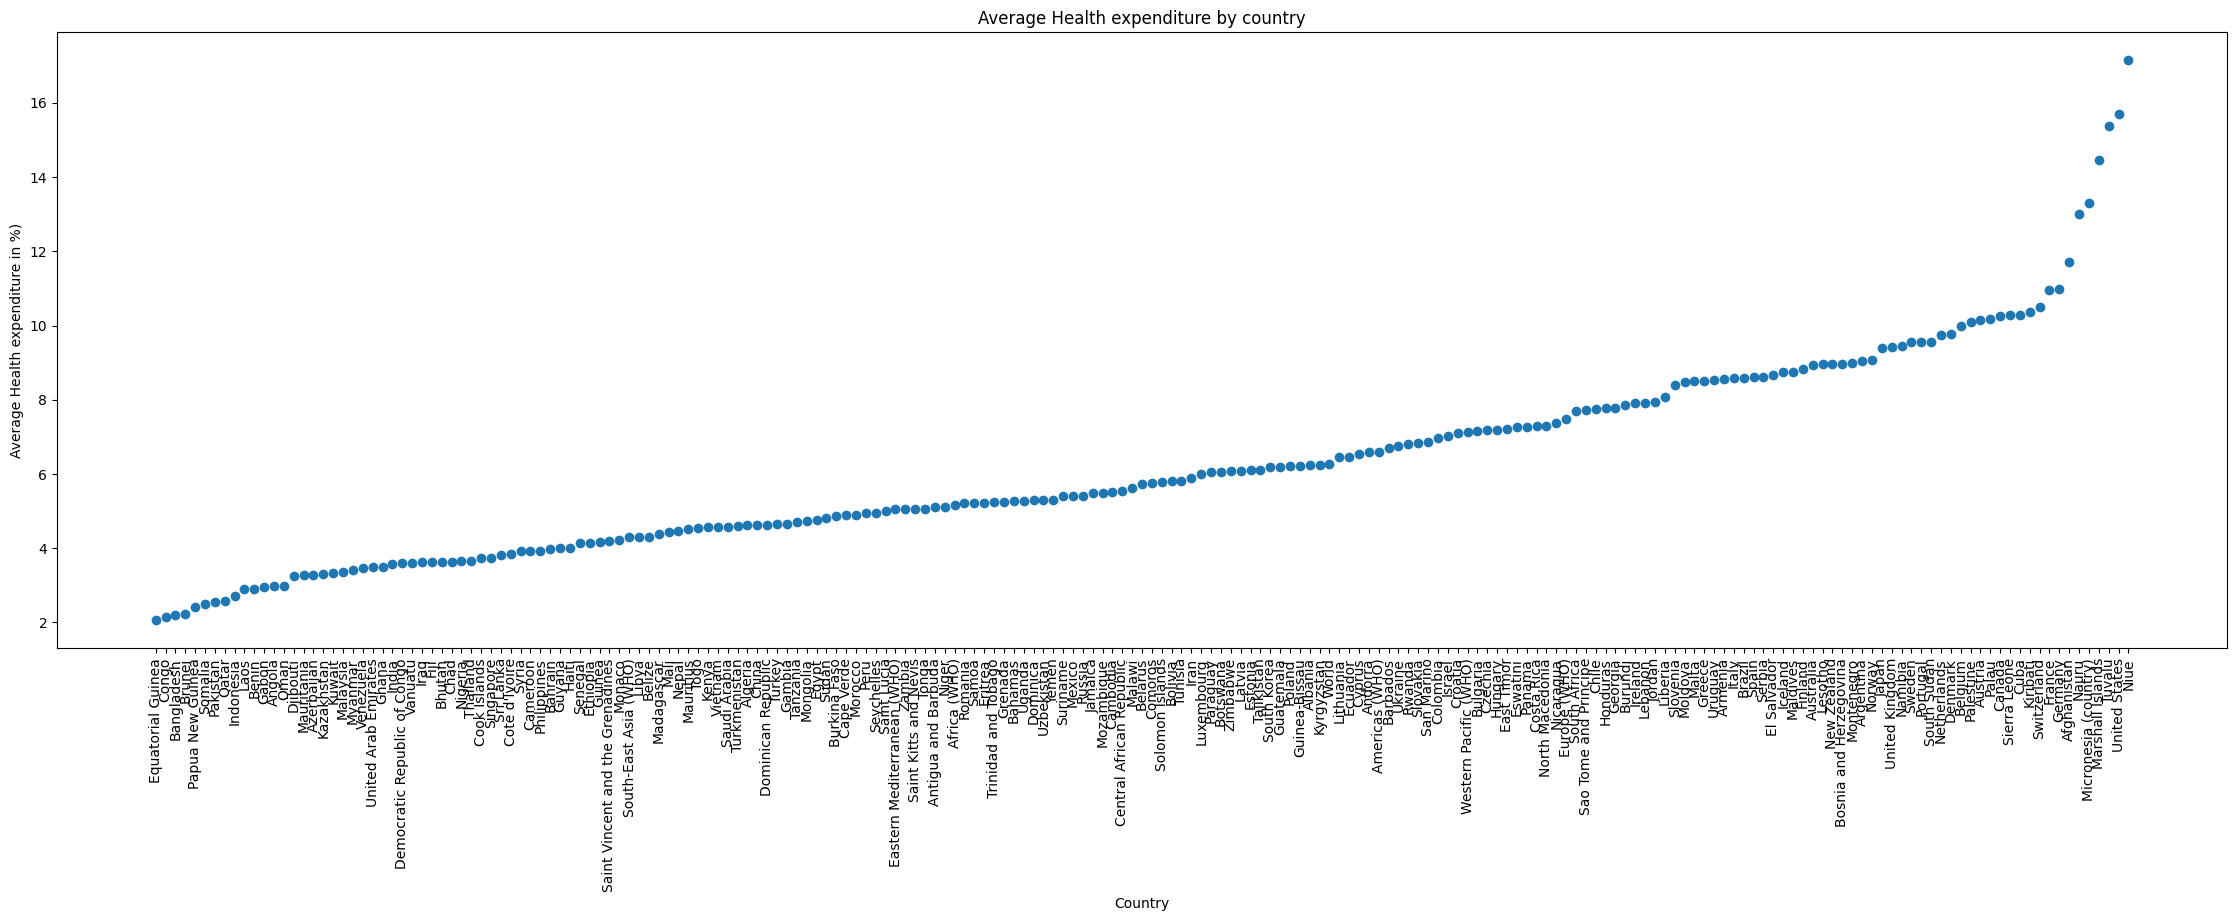

In [64]:
country_avg = (
    healthcare_df
    .groupby("Country", as_index=False)["Health_expenditure"]
    .mean()
    .sort_values(by="Health_expenditure")
)

plt.figure(figsize=(28, 8))
plt.scatter(country_avg["Country"], country_avg["Health_expenditure"])
plt.xlabel("Country")
plt.ylabel("Average Health expenditure in %)")
plt.title("Average Health expenditure by country")
plt.xticks(rotation=90)
plt.show()

It is not surprising that some poor countries has less healthcare expenditure than rich countries like United States.

Now, we can check the correlation between the happiness and the healthcare expenditure per capita between the 2 datasets.

Slope: 1.016
Intercept: 75.409
R²: 0.055


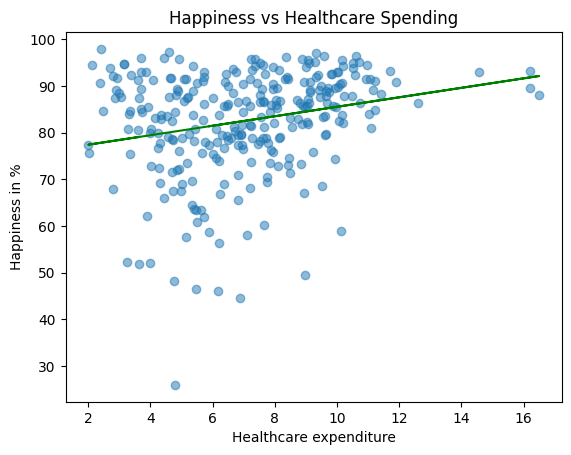

In [79]:
happy_health_df = pd.merge(
    happiness_df,
    healthcare_df,
    on=["Country", "Year"],
    how="inner"
)

happy_health_df = happy_health_df.dropna(subset=["Happiness", "Health_expenditure"])

X = happy_health_df[["Health_expenditure"]] 
y = happy_health_df["Happiness"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R²: {r_squared:.3f}")

plt.scatter(X, y, alpha=0.5)
plt.plot(X, model.predict(X), color='green')
plt.xlabel("Healthcare expenditure")
plt.ylabel("Happiness in %")
plt.title("Happiness vs Healthcare Spending")
plt.show()

Based on the results, seems like there is a slight positive association: more healthcare spending tends to correlate with slightly higher happiness. But the dependency is too low to conclude that the better is the healthcare, the happier is the person.

In [81]:
corruption_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28614 entries, 0 to 28613
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Entity                                         28614 non-null  object 
 1   Code                                           26548 non-null  object 
 2   Year                                           28614 non-null  int64  
 3   Political corruption index (central estimate)  28517 non-null  float64
 4   World region according to OWID                 272 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.1+ MB


In [84]:
corruption_df = corruption_df.rename(columns={'Entity': 'Country'})
corruption_df = corruption_df.rename(columns={'Political corruption index (central estimate)': 'Corruption'})

Here, the most interesting results will be 2 - which is the most corrupted country (result on which will come from how much the population trusts the government) and whether the less corrupted is country, the higher is its economic growth.

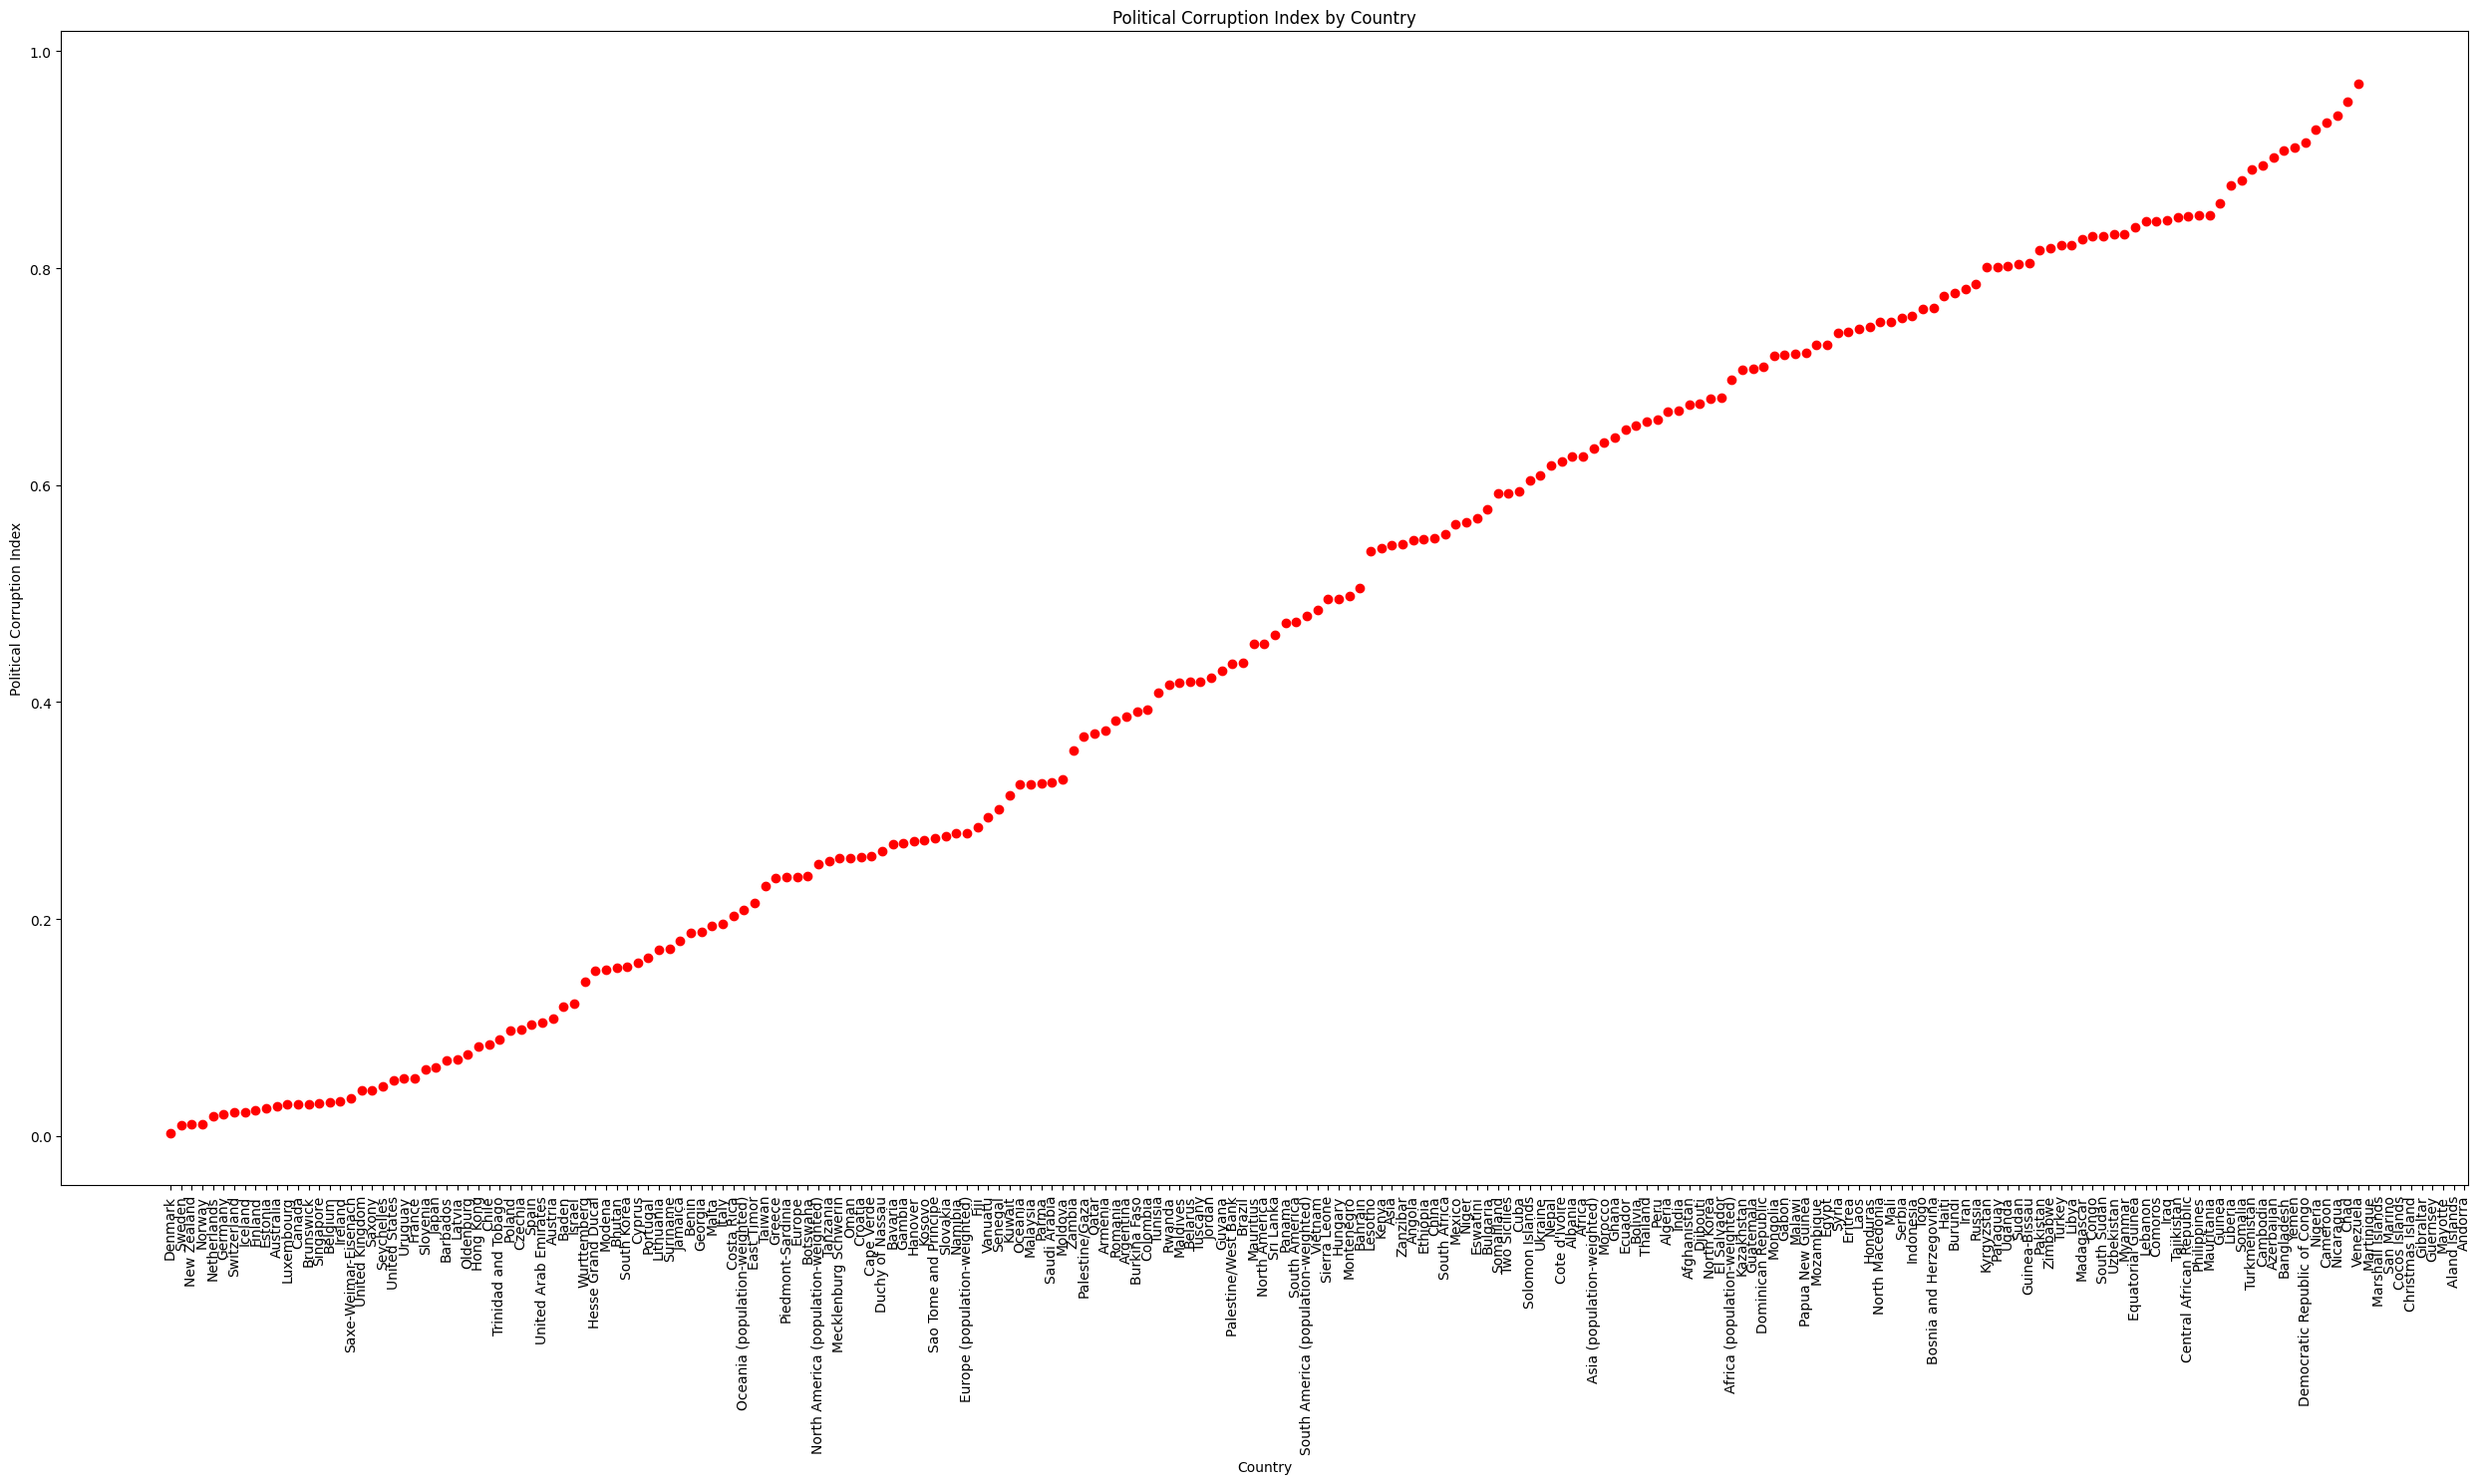

In [88]:
latest_data = corruption_df.sort_values('Year').groupby('Country').tail(1)

latest_data_sorted = latest_data.sort_values('Corruption', ascending=True)

plt.figure(figsize=(25,15))
plt.scatter(latest_data_sorted['Country'], latest_data_sorted['Corruption'], color='red')
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Political Corruption Index')
plt.title('Political Corruption Index by Country')
plt.tight_layout()
plt.show()

It is prety surprising that Andora is the most corrupted country. In oposit, Denmark is a well developed country in European union, so the lowest corruption is not unexpected.

Slope: -47412.185
Intercept: 43635.277
R²: 0.414


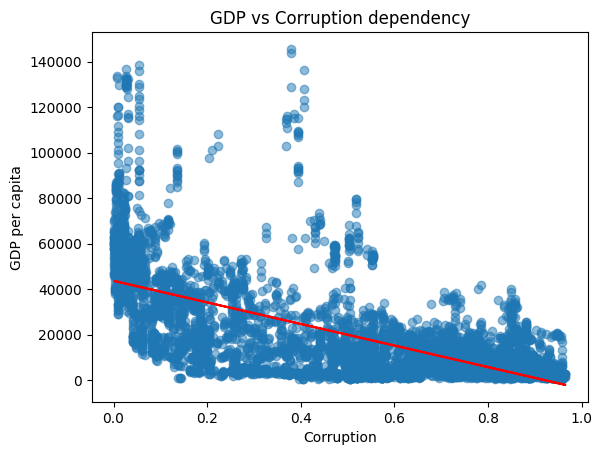

In [97]:
gdp_per_capita_df = gdp_per_capita_df.rename(columns={'GDP per capita, PPP (constant 2021 international $)': 'GDP_per_capita'})
gdp_per_capita_df = gdp_per_capita_df.rename(columns={'Entity': 'Country'})

gdp_corrupt_df = pd.merge(
    gdp_per_capita_df,
    corruption_df,
    on=["Country", "Year"],
    how="inner"
)

gdp_corrupt_df = gdp_corrupt_df.dropna(subset=["GDP_per_capita", "Corruption"])

X = gdp_corrupt_df[["Corruption"]]
y = gdp_corrupt_df["GDP_per_capita"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R²: {r_squared:.3f}")

plt.scatter(X, y, alpha=0.5)
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Corruption")
plt.ylabel("GDP per capita")
plt.title("GDP vs Corruption dependency")
plt.show()

It is visible that the correlation is below 0, and the assumption was confirmed. We can't be surprised that if the corruption in one country is bigger, the economic growth wouldn't be enormous.

The GDP per capita through the contries is the main factor of country economics growth as well as overal place of each country on the world map. Let's now investigate this field of study.

In [7]:
gdp_per_capita_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7311 entries, 0 to 7310
Data columns (total 5 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               7311 non-null   object 
 1   Code                                                 6876 non-null   object 
 2   Year                                                 7311 non-null   int64  
 3   GDP per capita, PPP (constant 2021 international $)  7236 non-null   float64
 4   World region according to OWID                       272 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 285.7+ KB


In [75]:
gdp_per_capita_df = gdp_per_capita_df.rename(columns={'GDP per capita, PPP (constant 2021 international $)': 'GDP_per_capita'})
gdp_per_capita_df = gdp_per_capita_df.rename(columns={'Entity': 'Country'})

The most important one, let's compare the GDP per capita over different countries

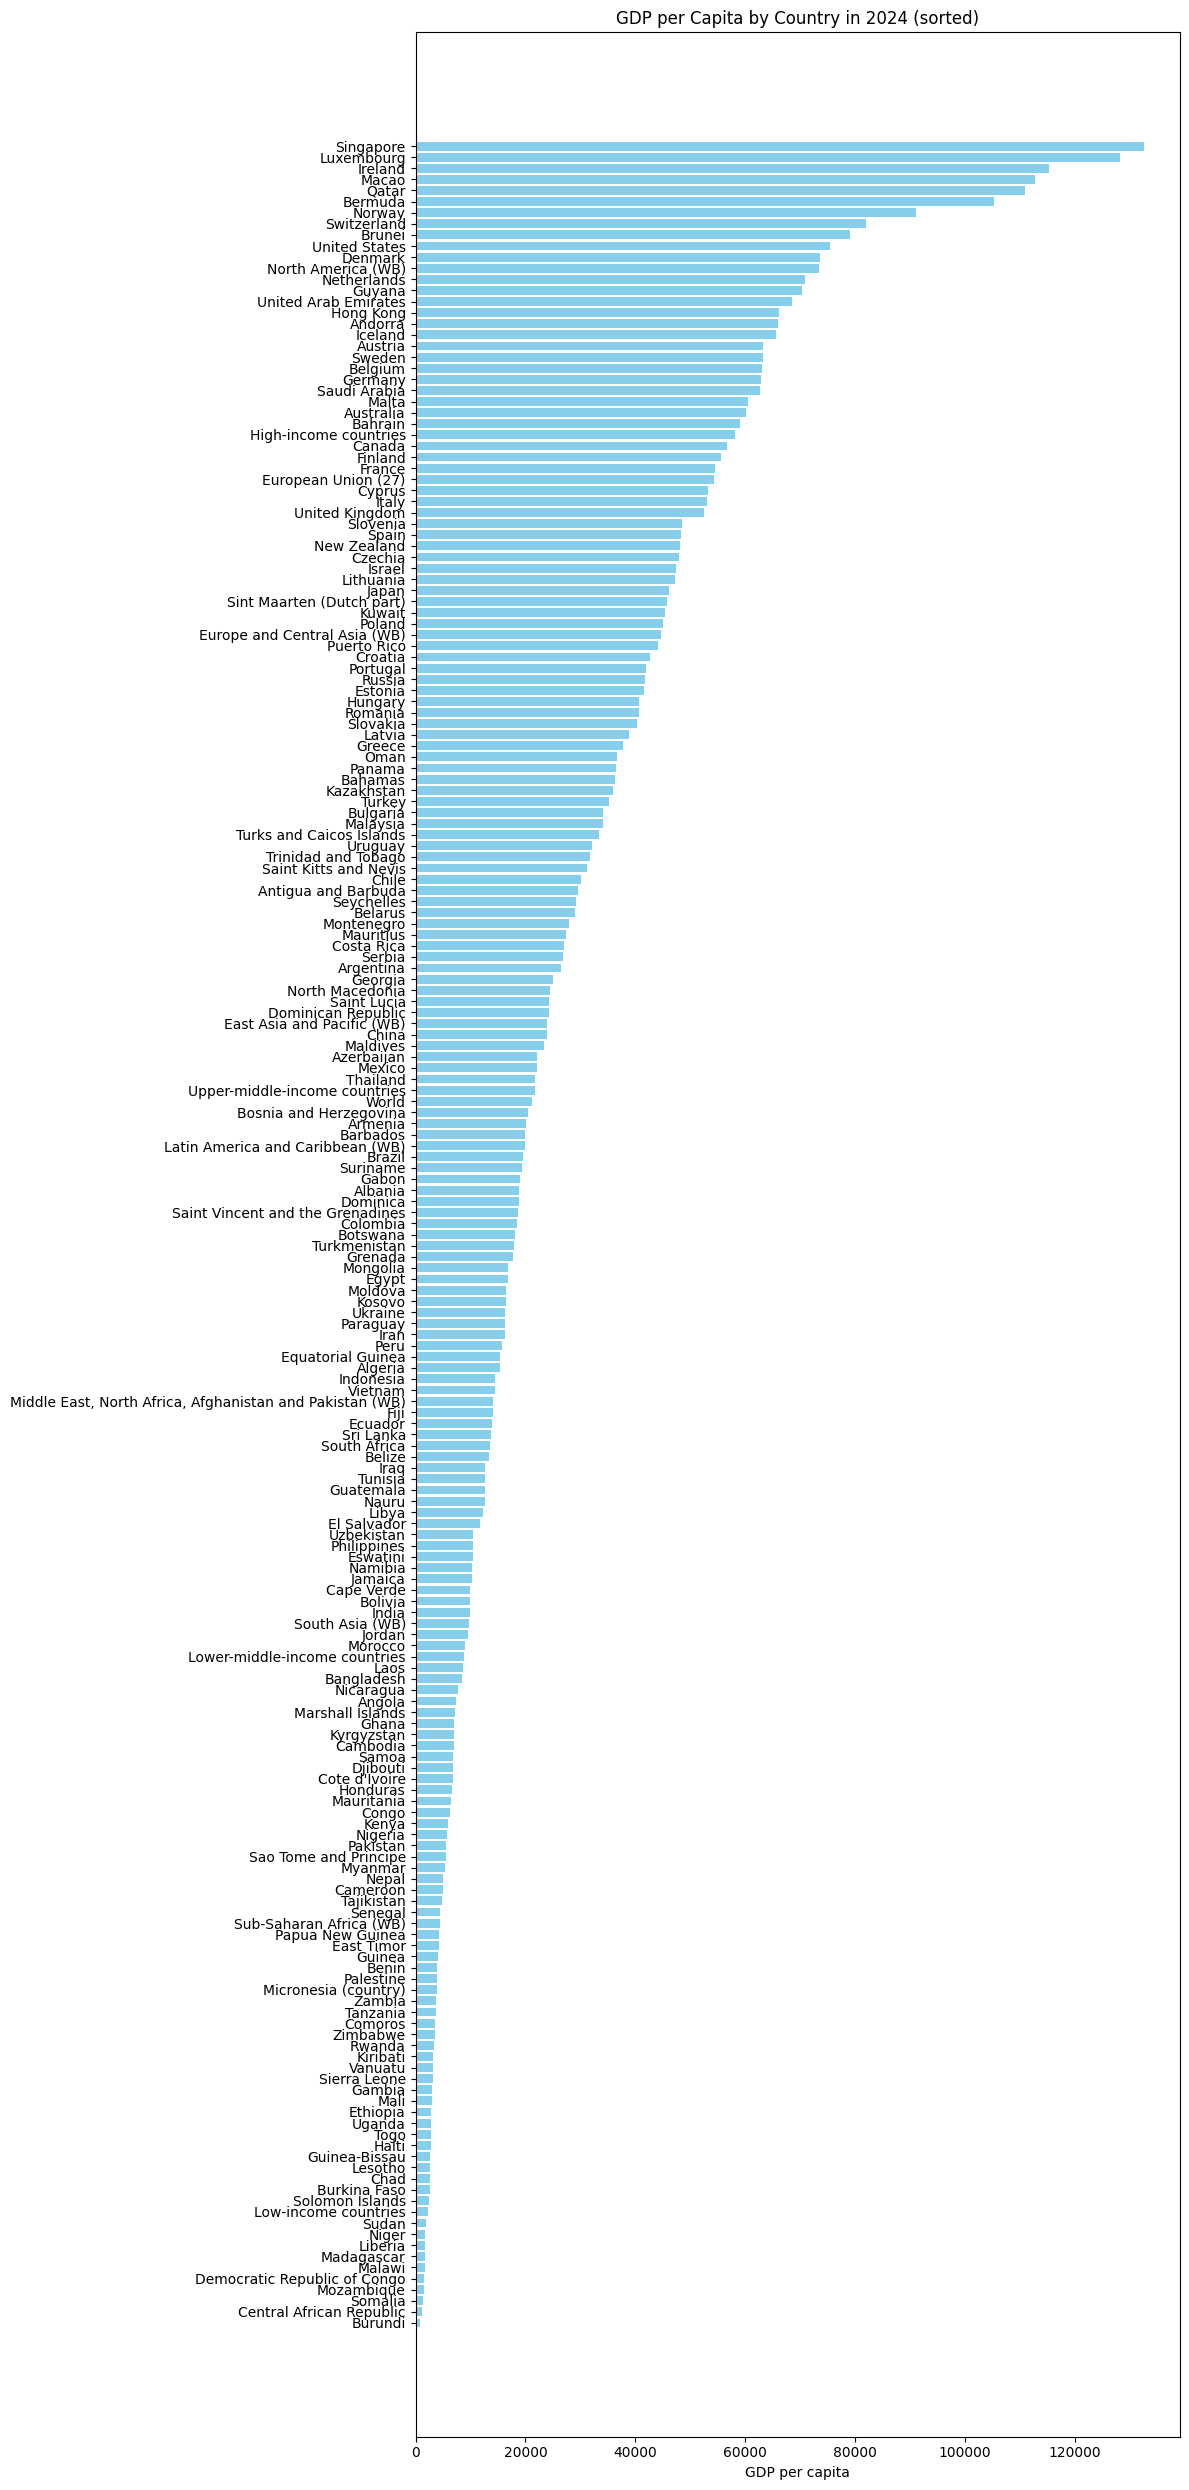

In [72]:
latest_year = gdp_per_capita_df['Year'].max()
latest_gdp = gdp_per_capita_df[gdp_per_capita_df['Year'] == latest_year]


latest_gdp = latest_gdp.dropna(subset=["GDP_per_capita"])

latest_gdp = latest_gdp.sort_values(by="GDP_per_capita")

plt.figure(figsize=(12,25))
plt.barh(latest_gdp['Entity'], latest_gdp["GDP_per_capita"], color='skyblue')
plt.xlabel("GDP per capita")
plt.title(f"GDP per Capita by Country in {latest_year} (sorted)")
plt.tight_layout()
plt.show()

Let's now compare whether if the GDP per capita is more, the money which are spend for healthcare are more:

Slope: 1518.740
Intercept: 12088.966
R²: 0.035


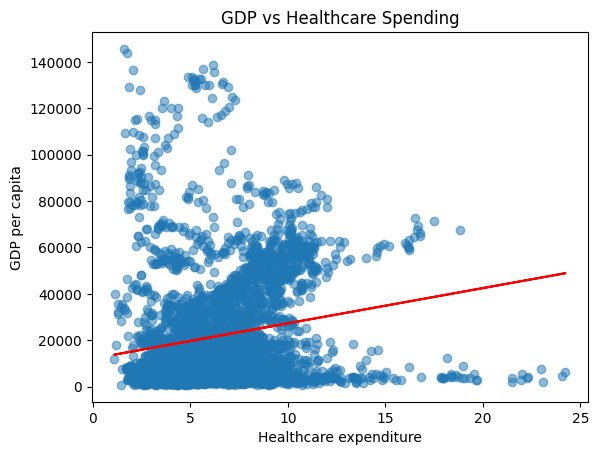

In [78]:
gdp_health_df = pd.merge(
    gdp_per_capita_df,
    healthcare_df,
    on=["Country", "Year"],
    how="inner"
)

gdp_health_df = gdp_health_df.dropna(subset=["GDP_per_capita", "Health_expenditure"])

X = gdp_health_df[["Health_expenditure"]] 
y = gdp_health_df["GDP_per_capita"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R²: {r_squared:.3f}")

plt.scatter(X, y, alpha=0.5)
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Healthcare expenditure")
plt.ylabel("GDP per capita")
plt.title("GDP vs Healthcare Spending")
plt.show()

Based on the measured results, here the slope is steeper, so although the correlation is not close to 1, we can actually spot a small connection between these two parameters.